In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision
from torchvision import transforms, datasets
import os,PIL,pathlib,warnings
import os,PIL,random,pathlib


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [4]:
data_dir = '/content/drive/MyDrive/weather_photos'
data_dir = pathlib.Path(data_dir)

data_paths  = list(data_dir.glob('*'))
classeNames = [path.name for path in data_paths]
classeNames

['cloudy', 'rain', 'shine', 'sunrise']

In [5]:
# For more information about transforms.Compose, please refer to: https://blog.csdn.net/qq_38251616/article/details/124878863
train_transforms = transforms.Compose([
    transforms.Resize([224, 224]),  # Resize the input image to a uniform size
    # transforms.RandomHorizontalFlip(), # Random horizontal flip
    transforms.ToTensor(),          # Convert PIL Image or numpy.ndarray to tensor and normalize to [0,1]
    transforms.Normalize(           # Standardization -> Convert to standard normal distribution (Gaussian distribution) to make the model easier to converge
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])  # Where mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225] are calculated by random sampling from the dataset.
])

test_transform = transforms.Compose([
    transforms.Resize([224, 224]),  # Resize the input image to a uniform size
    transforms.ToTensor(),          # Convert PIL Image or numpy.ndarray to tensor and normalize to [0,1]
    transforms.Normalize(           # Standardization -> Convert to standard normal distribution (Gaussian distribution) to make the model easier to converge
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225])  # Where mean=[0.485,0.456,0.406] and std=[0.229,0.224,0.225] are calculated by random sampling from the dataset.
])

total_data = datasets.ImageFolder("/content/drive/MyDrive/weather_photos",transform=train_transforms)


In [6]:
total_data

Dataset ImageFolder
    Number of datapoints: 1125
    Root location: /content/drive/MyDrive/weather_photos
    StandardTransform
Transform: Compose(
               Resize(size=[224, 224], interpolation=bilinear, max_size=None, antialias=True)
               ToTensor()
               Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
           )

In [7]:
total_data.class_to_idx

{'cloudy': 0, 'rain': 1, 'shine': 2, 'sunrise': 3}

Splitting Dataset

In [8]:
train_size = int(0.8 * len(total_data))
test_size  = len(total_data) - train_size
train_dataset, test_dataset = torch.utils.data.random_split(total_data, [train_size, test_size])
train_dataset, test_dataset

(<torch.utils.data.dataset.Subset at 0x7a68c19792d0>,
 <torch.utils.data.dataset.Subset at 0x7a68c19792a0>)

In [9]:
batch_size = 4

train_dl = torch.utils.data.DataLoader(train_dataset,
                                           batch_size=batch_size,
                                           shuffle=True,
                                           num_workers=1)
test_dl = torch.utils.data.DataLoader(test_dataset,
                                          batch_size=batch_size,
                                          shuffle=True,
                                          num_workers=1)

In [10]:
for X, y in test_dl:
    print("Shape of X [N, C, H, W]: ", X.shape)
    print("Shape of y: ", y.shape, y.dtype)
    break

Shape of X [N, C, H, W]:  torch.Size([4, 3, 224, 224])
Shape of y:  torch.Size([4]) torch.int64


In [11]:
import torch.nn.functional as F

def autopad(k, p=None):  # kernel, padding
    # Pad to 'same'
    if p is None:
        p = k // 2 if isinstance(k, int) else [x // 2 for x in k]  # auto-pad
    return p

class Conv(nn.Module):
    # Standard convolution
    def __init__(self, c1, c2, k=1, s=1, p=None, g=1, act=True):  # ch_in, ch_out, kernel, stride, padding, groups
        super().__init__()
        self.conv = nn.Conv2d(c1, c2, k, s, autopad(k, p), groups=g, bias=False)
        self.bn = nn.BatchNorm2d(c2)
        self.act = nn.SiLU() if act is True else (act if isinstance(act, nn.Module) else nn.Identity())

    def forward(self, x):
        return self.act(self.bn(self.conv(x)))

class Bottleneck(nn.Module):
    # Standard bottleneck
    def __init__(self, c1, c2, shortcut=True, g=1, e=0.5):  # ch_in, ch_out, shortcut, groups, expansion
        super().__init__()
        c_ = int(c2 * e)  # hidden channels
        self.cv1 = Conv(c1, c_, 1, 1)
        self.cv2 = Conv(c_, c2, 3, 1, g=g)
        self.add = shortcut and c1 == c2

    def forward(self, x):
        return x + self.cv2(self.cv1(x)) if self.add else self.cv2(self.cv1(x))

class C3(nn.Module):
    # CSP Bottleneck with 3 convolutions
    def __init__(self, c1, c2, n=1, shortcut=True, g=1, e=0.5):  # ch_in, ch_out, number, shortcut, groups, expansion
        super().__init__()
        c_ = int(c2 * e)  # hidden channels
        self.cv1 = Conv(c1, c_, 1, 1)
        self.cv2 = Conv(c1, c_, 1, 1)
        self.cv3 = Conv(2 * c_, c2, 1)  # act=FReLU(c2)
        self.m = nn.Sequential(*(Bottleneck(c_, c_, shortcut, g, e=1.0) for _ in range(n)))

    def forward(self, x):
        return self.cv3(torch.cat((self.m(self.cv1(x)), self.cv2(x)), dim=1))

class model_K(nn.Module):
    def __init__(self):
        super(model_K, self).__init__()

        # Conv
        self.Conv = Conv(3, 32, 3, 2)

        # C3 module 1
        self.C3_1 = C3(32, 64, 3, 2)

        # Full connected layer
        self.classifier = nn.Sequential(
            nn.Linear(in_features=802816, out_features=100),
            nn.ReLU(),
            nn.Linear(in_features=100, out_features=4)
        )

    def forward(self, x):
        x = self.Conv(x)
        x = self.C3_1(x)
        x = torch.flatten(x, start_dim=1)
        x = self.classifier(x)

        return x

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using {} device".format(device))

model = model_K().to(device)
model

Using cuda device


model_K(
  (Conv): Conv(
    (conv): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (act): SiLU()
  )
  (C3_1): C3(
    (cv1): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
    (cv2): Conv(
      (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
    (cv3): Conv(
      (conv): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (act): SiLU()
    )
    (m): Sequential(
      (0): Bottleneck(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1

In [12]:
import torchsummary as summary
summary.summary(model, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 112, 112]             864
       BatchNorm2d-2         [-1, 32, 112, 112]              64
              SiLU-3         [-1, 32, 112, 112]               0
              Conv-4         [-1, 32, 112, 112]               0
            Conv2d-5         [-1, 32, 112, 112]           1,024
       BatchNorm2d-6         [-1, 32, 112, 112]              64
              SiLU-7         [-1, 32, 112, 112]               0
              Conv-8         [-1, 32, 112, 112]               0
            Conv2d-9         [-1, 32, 112, 112]           1,024
      BatchNorm2d-10         [-1, 32, 112, 112]              64
             SiLU-11         [-1, 32, 112, 112]               0
             Conv-12         [-1, 32, 112, 112]               0
           Conv2d-13         [-1, 32, 112, 112]           9,216
      BatchNorm2d-14         [-1, 32, 1

test

In [13]:
# Training loop
def train(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)  # Size of the training dataset
    num_batches = len(dataloader)   # Number of batches, (size/batch_size, rounded up)

    train_loss, train_acc = 0, 0  # Initialize training loss and accuracy

    for X, y in dataloader:  # Get image and its label
        X, y = X.to(device), y.to(device)  # Move data to the device (GPU if available, otherwise CPU)

        # Compute prediction error
        pred = model(X)          # Network output
        loss = loss_fn(pred, y)  # Calculate the difference between network output and true value,
                                 # targets is the true value, calculating the difference between the two is the loss

        # Backpropagation
        optimizer.zero_grad()  # Reset gradients to zero
        loss.backward()        # Backpropagation
        optimizer.step()       # Update model parameters

        # Record accuracy and loss
        train_acc  += (pred.argmax(1) == y).type(torch.float).sum().item()  # Calculate and accumulate correct predictions
        train_loss += loss.item()  # Accumulate loss

    train_acc  /= size  # Calculate average accuracy
    train_loss /= num_batches  # Calculate average loss

    return train_acc, train_loss  # Return accuracy and loss

In [14]:
def test(dataloader, model, loss_fn):
    size = len(dataloader.dataset)  # Size of the test dataset
    num_batches = len(dataloader)  # Number of batches, (size/batch_size, rounded up)
    test_loss, test_acc = 0, 0

    # Disable gradient updates for inference to save memory and computation
    with torch.no_grad():
        for imgs, target in dataloader:
            imgs, target = imgs.to(device), target.to(device)  # Move data to the device

            # Compute loss
            target_pred = model(imgs)  # Model prediction
            loss = loss_fn(target_pred, target)  # Calculate loss

            test_loss += loss.item()  # Accumulate loss
            test_acc += (target_pred.argmax(1) == target).type(torch.float).sum().item()  # Accumulate correct predictions

    test_acc /= size  # Calculate average accuracy
    test_loss /= num_batches  # Calculate average loss

    return test_acc, test_loss  # Return accuracy and loss

In [15]:
import copy

# Define optimizer and loss function
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)
loss_fn = nn.CrossEntropyLoss()  # Create loss function

# Set training parameters
epochs = 20

# Initialize lists to store training and testing metrics
train_loss = []
train_acc = []
test_loss = []
test_acc = []

best_acc = 0  # Set an initial best accuracy for model selection

# Training loop
for epoch in range(epochs):

    model.train()  # Set the model to training mode
    epoch_train_acc, epoch_train_loss = train(train_dl, model, loss_fn, optimizer)  # Train the model for one epoch

    model.eval()  # Set the model to evaluation mode
    epoch_test_acc, epoch_test_loss = test(test_dl, model, loss_fn)  # Evaluate the model on the test set

    # Save the best model based on test accuracy
    if epoch_test_acc > best_acc:
        best_acc = epoch_test_acc
        best_model = copy.deepcopy(model)  # Create a deep copy of the best model

    # Append metrics to lists for tracking
    train_acc.append(epoch_train_acc)
    train_loss.append(epoch_train_loss)
    test_acc.append(epoch_test_acc)
    test_loss.append(epoch_test_loss)

    # Get current learning rate
    lr = optimizer.state_dict()['param_groups'][0]['lr']

    # Print training progress
    template = ('Epoch:{:2d}, Train_acc:{:.1f}%, Train_loss:{:.3f}, Test_acc:{:.1f}%, Test_loss:{:.3f}, Lr:{:.2E}')
    print(template.format(epoch + 1, epoch_train_acc * 100, epoch_train_loss,
                          epoch_test_acc * 100, epoch_test_loss, lr))

# Save the best model to a file
PATH = './best_model.pth'  # File name for saving the model parameters
torch.save(model.state_dict(), PATH)

print('Finished')

Epoch: 1, Train_acc:70.3%, Train_loss:1.355, Test_acc:81.3%, Test_loss:1.010, Lr:1.00E-04
Epoch: 2, Train_acc:86.1%, Train_loss:0.421, Test_acc:86.7%, Test_loss:0.415, Lr:1.00E-04
Epoch: 3, Train_acc:89.0%, Train_loss:0.336, Test_acc:86.7%, Test_loss:0.425, Lr:1.00E-04
Epoch: 4, Train_acc:93.9%, Train_loss:0.191, Test_acc:86.7%, Test_loss:0.413, Lr:1.00E-04
Epoch: 5, Train_acc:96.7%, Train_loss:0.112, Test_acc:87.6%, Test_loss:0.473, Lr:1.00E-04
Epoch: 6, Train_acc:96.6%, Train_loss:0.137, Test_acc:88.4%, Test_loss:0.590, Lr:1.00E-04
Epoch: 7, Train_acc:97.0%, Train_loss:0.088, Test_acc:90.7%, Test_loss:0.376, Lr:1.00E-04
Epoch: 8, Train_acc:97.2%, Train_loss:0.090, Test_acc:89.3%, Test_loss:0.496, Lr:1.00E-04
Epoch: 9, Train_acc:96.1%, Train_loss:0.167, Test_acc:88.0%, Test_loss:0.752, Lr:1.00E-04
Epoch:10, Train_acc:98.9%, Train_loss:0.054, Test_acc:88.0%, Test_loss:0.596, Lr:1.00E-04
Epoch:11, Train_acc:99.0%, Train_loss:0.034, Test_acc:87.6%, Test_loss:0.531, Lr:1.00E-04
Epoch:12, 

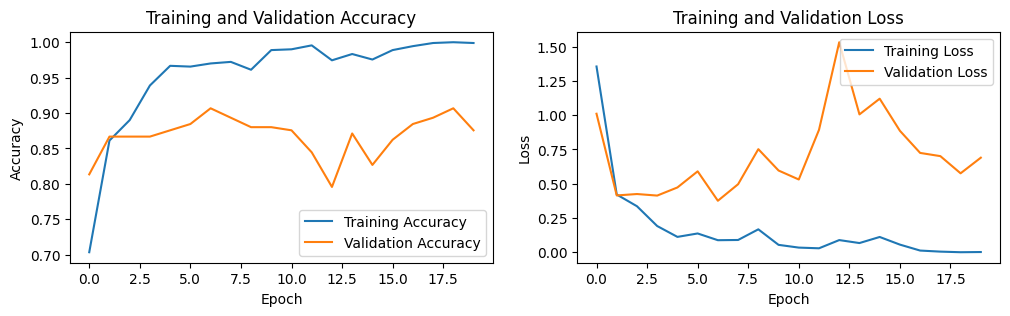

In [16]:
import matplotlib.pyplot as plt

# Hide warnings
import warnings
warnings.filterwarnings("ignore")  # Ignore warning messages

# Set Matplotlib parameters for better visualization
plt.rcParams['font.sans-serif'] = ['SimHei']  # Use SimHei font for Chinese characters (if needed)
plt.rcParams['axes.unicode_minus'] = False  # Ensure negative signs display correctly
plt.rcParams['figure.dpi'] = 100  # Set resolution

epochs_range = range(epochs)

# Create a figure with two subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 3))

# Plot training and validation accuracy
ax1.plot(epochs_range, train_acc, label='Training Accuracy')
ax1.plot(epochs_range, test_acc, label='Validation Accuracy')  # Changed to 'Validation Accuracy'
ax1.legend(loc='lower right')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')

# Plot training and validation loss
ax2.plot(epochs_range, train_loss, label='Training Loss')
ax2.plot(epochs_range, test_loss, label='Validation Loss')  # Changed to 'Validation Loss'
ax2.legend(loc='upper right')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')

plt.show()

In [17]:
best_model.eval()
epoch_test_acc, epoch_test_loss = test(test_dl, best_model, loss_fn)

In [18]:
epoch_test_acc, epoch_test_loss

(0.9066666666666666, 0.37583882772797517)